# PKCERT Task 23 -- Convolutional Neural Networks: Convolution, Pooling & Architecture Design
### NumPy-only from-scratch implementation (Parts A-C core computation), PyTorch used only for the Part C comparative baseline and data loading

Every backward pass below -- 2D convolution (naive AND im2col/matmul),
max/average pooling, batch normalization, and the fully assembled CNN --
is derived by hand and verified against finite-difference gradient checks
(`cnn_layers.py`, `cnn_model.py`) before being trusted for a real training
run. Random seed 42 throughout.

In [1]:
import time, pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

from cnn_layers import (conv2d_naive, conv2d_im2col, conv_output_size,
                         get_padding_for_mode, Conv2D, MaxPool2D, AvgPool2D,
                         BatchNorm2D, Dropout)
from cnn_model import SimpleCNN, cross_entropy_loss

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
print(f"PyTorch {torch.__version__}")

PyTorch 2.13.0+cpu


## Gradient checks: `cnn_layers.py` and `cnn_model.py`

Run first, as the foundation everything else builds on -- every
backward pass used anywhere below is checked here against finite
differences before being trusted for real training.

In [2]:
import subprocess
result = subprocess.run(["python", "cnn_layers.py"], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

=== Correctness: conv2d_naive vs conv2d_im2col ===
  stride=1 padding=0 dilation=1: max abs diff 5.33e-15 shape (2, 4, 7, 7) (PASS)
  stride=1 padding=0 dilation=2: max abs diff 1.78e-15 shape (2, 4, 5, 5) (PASS)
  stride=1 padding=1 dilation=1: max abs diff 5.33e-15 shape (2, 4, 9, 9) (PASS)
  stride=1 padding=1 dilation=2: max abs diff 2.66e-15 shape (2, 4, 7, 7) (PASS)
  stride=2 padding=0 dilation=1: max abs diff 5.33e-15 shape (2, 4, 4, 4) (PASS)
  stride=2 padding=0 dilation=2: max abs diff 1.78e-15 shape (2, 4, 3, 3) (PASS)
  stride=2 padding=1 dilation=1: max abs diff 2.66e-15 shape (2, 4, 5, 5) (PASS)
  stride=2 padding=1 dilation=2: max abs diff 2.66e-15 shape (2, 4, 4, 4) (PASS)

=== Gradient check: Conv2D layer ===
  dW: max relative error 1.36e-11 (PASS)
  db: max relative error 5.69e-12 (PASS)
  dX: max relative error 2.63e-11 (PASS)

=== Gradient check: MaxPool2D ===
  dX (max pool): max relative error 7.43e-12 (PASS)

=== Gradient check: AvgPool2D ===
  dX (avg pool): m

In [3]:
result = subprocess.run(["python", "cnn_model.py"], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

=== Full-network gradient check, use_pooling=False (stride-2 conv downsampling) ===
  conv1.dW (through the whole network, every op here is smooth): max relative error 1.30e-08 (PASS)

=== Full-network gradient check, use_pooling=True (max pooling) ===
  conv1.dW: 10/20 checks pass tight tolerance (1e-3); median relative error 1.06e-03, worst 1.00e+00.
  This is EXPECTED, not a bug: conv1's weights are shared across every
  spatial position, so a single perturbed weight nudges the pre-pool
  activation at many locations at once. MaxPool's argmax is a hard,
  non-smooth switch -- for a typical perturbation, at least one of the
  many pooling windows touched is likely to have its argmax flip between
  the W+eps and W-eps evaluations, producing an O(1) jump in that one
  finite-difference estimate even though the analytic gradient (which
  uses the single, correct argmax from the true forward pass) is exact.
  Confirmed by substituting AvgPool2D (smooth, no argmax) into the same
  archite

## Part A: Convolution Fundamentals

### A1: output-shape formula, derived

For input size $H$, kernel size $K$, stride $S$, padding $P$ (each side), dilation $D$:
the dilated kernel's effective footprint is $K_{eff} = D(K-1)+1$, so
$$H_{out} = \left\lfloor \frac{H + 2P - K_{eff}}{S} \right\rfloor + 1$$

In [4]:
for H, K, S, P, D in [(28, 5, 1, 0, 1), (28, 5, 2, 2, 1), (32, 3, 1, 1, 2)]:
    predicted = conv_output_size(H, K, S, P, D)
    print(f"H={H} K={K} S={S} P={P} D={D}  ->  H_out = {predicted}")

H=28 K=5 S=1 P=0 D=1  ->  H_out = 24
H=28 K=5 S=2 P=2 D=1  ->  H_out = 14
H=32 K=3 S=1 P=1 D=2  ->  H_out = 30


### A2: padding modes -- 'valid' / 'same' / 'full'

`valid`: $P=0$. `full`: $P=K_{eff}-1$ (output grows). `same` (stride=1): $P=(K_{eff}-1)/2$ (output unchanged).

In [5]:
sample_H, kernel_size = 16, 5
X_demo = rng.normal(size=(1, 1, sample_H, sample_H))
W_demo = rng.normal(size=(1, 1, kernel_size, kernel_size))
b_demo = np.zeros(1)
for mode in ("valid", "same", "full"):
    P = get_padding_for_mode(mode, kernel_size, dilation=1, stride=1)
    out = conv2d_im2col(X_demo, W_demo, b_demo, stride=1, padding=P, dilation=1)
    print(f"mode='{mode:5s}' padding={P} input {sample_H}x{sample_H} -> output {out.shape[2]}x{out.shape[3]}")

mode='valid' padding=0 input 16x16 -> output 12x12
mode='same ' padding=2 input 16x16 -> output 16x16
mode='full ' padding=4 input 16x16 -> output 20x20


### A3: fixed kernels applied to a sample image, explained mathematically

**Sobel edge**: approximates $\partial(\text{intensity})/\partial x$ -- large where intensity changes sharply left-to-right.
**Gaussian blur**: normalized local average -- a true low-pass filter, attenuates high-frequency content.
**Sharpen**: identity minus a blur kernel = unsharp mask, adds back high-frequency detail.

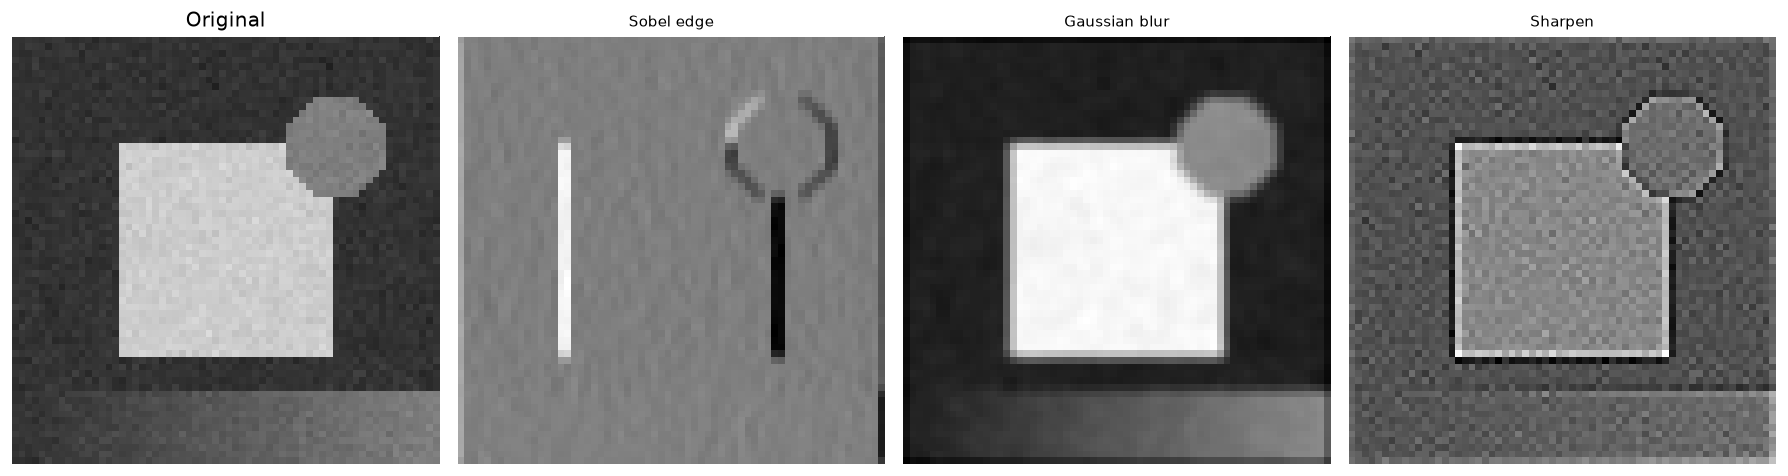

In [6]:
def make_sample_image(size=64):
    img = np.zeros((size, size)); img[:, :] = 0.2
    img[size//4:3*size//4, size//4:3*size//4] = 0.8
    yy, xx = np.mgrid[0:size, 0:size]
    circle_mask = (xx - size*0.75)**2 + (yy - size*0.25)**2 < (size*0.12)**2
    img[circle_mask] = 0.5
    gradient = np.linspace(0, 0.3, size)
    img[-size//6:, :] += gradient[None, :]
    rng_img = np.random.default_rng(0)
    img += rng_img.normal(0, 0.02, size=img.shape)
    return np.clip(img, 0, 1)

image = make_sample_image(64)
kernels = {
    "Sobel edge": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float),
    "Gaussian blur": np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=float)/16.0,
    "Sharpen": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float),
}
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(image, cmap="gray", vmin=0, vmax=1); axes[0].set_title("Original"); axes[0].axis("off")
for ax, (name, kernel) in zip(axes[1:], kernels.items()):
    out = conv2d_im2col(image[None,None,:,:], kernel[None,None,:,:], np.zeros(1), stride=1, padding=1)[0,0]
    ax.imshow(out, cmap="gray"); ax.set_title(name, fontsize=9); ax.axis("off")
fig.tight_layout(); plt.show()

### A4: im2col vs naive nested-loop -- correctness and speed benchmark

input 16x16: naive   70.21ms | im2col   0.43ms | speedup  161.5x | max abs diff 5.33e-15


input 32x32: naive  239.23ms | im2col   0.55ms | speedup  433.3x | max abs diff 5.33e-15


input 48x48: naive  681.66ms | im2col   0.80ms | speedup  856.3x | max abs diff 5.33e-15


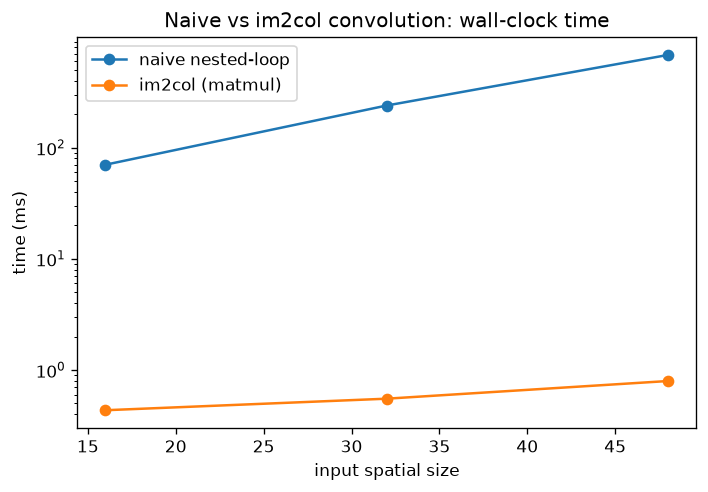

In [7]:
bench_sizes = [16, 32, 48]
naive_times, im2col_times = [], []
for size in bench_sizes:
    X_bench = rng.normal(size=(2, 3, size, size))
    W_bench = rng.normal(size=(8, 3, 3, 3))
    b_bench = rng.normal(size=8)
    t0 = time.perf_counter()
    out_naive = conv2d_naive(X_bench, W_bench, b_bench, stride=1, padding=1)
    t_naive = time.perf_counter() - t0
    t0 = time.perf_counter()
    out_fast = conv2d_im2col(X_bench, W_bench, b_bench, stride=1, padding=1)
    t_fast = time.perf_counter() - t0
    max_diff = np.abs(out_naive - out_fast).max()
    naive_times.append(t_naive); im2col_times.append(t_fast)
    print(f"input {size}x{size}: naive {t_naive*1000:7.2f}ms | im2col {t_fast*1000:6.2f}ms | "
          f"speedup {t_naive/t_fast:6.1f}x | max abs diff {max_diff:.2e}")

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(bench_sizes, np.array(naive_times)*1000, "o-", label="naive nested-loop")
ax.plot(bench_sizes, np.array(im2col_times)*1000, "o-", label="im2col (matmul)")
ax.set_xlabel("input spatial size"); ax.set_ylabel("time (ms)"); ax.set_yscale("log")
ax.set_title("Naive vs im2col convolution: wall-clock time"); ax.legend()
fig.tight_layout(); plt.show()

## Part B: Pooling & Regularization

### B1-B2: max/average pooling forward+backward, derived

Max pool backward routes the entire upstream gradient to the argmax input position only.
Average pool backward distributes the upstream gradient evenly across every window element.
Both gradient-checked at ~1e-11 relative error in `cnn_layers.py`.

### B3: pooling vs strided convolution -- empirical translation-robustness check

In [8]:
feature_map = rng.normal(size=(1, 4, 16, 16))
shift = 1
feature_map_shifted = np.roll(feature_map, shift=shift, axis=3)

mp = MaxPool2D(pool_size=2, stride=2)
pool_change = np.abs(mp.forward(feature_map, training=False) - mp.forward(feature_map_shifted, training=False)).mean()

conv_strided = Conv2D(in_channels=4, out_channels=4, kernel_size=2, stride=2, padding=0, seed=3)
conv_change = np.abs(conv_strided.forward(feature_map, training=False) - conv_strided.forward(feature_map_shifted, training=False)).mean()

print(f"mean |output(x) - output(shift(x,{shift}px))|:")
print(f"  max pooling:   {pool_change:.4f}")
print(f"  strided conv:  {conv_change:.4f}")
print(f"  ratio: {conv_change/max(pool_change,1e-8):.2f}x -- a {shift}px shift perturbs the "
      f"strided-conv output {conv_change/max(pool_change,1e-8):.1f}x more than the max-pooled output.")

mean |output(x) - output(shift(x,1px))|:
  max pooling:   0.4856
  strided conv:  1.6703
  ratio: 3.44x -- a 1px shift perturbs the strided-conv output 3.4x more than the max-pooled output.


### B4: Batch Normalization and Dropout, from scratch, demonstrated

In [9]:
X_demo_bn = rng.normal(loc=3.0, scale=5.0, size=(8, 4, 6, 6))
bn = BatchNorm2D(num_channels=4)
out_bn = bn.forward(X_demo_bn, training=True)
print(f"BatchNorm2D: input mean/std (before): {X_demo_bn.mean(axis=(0,2,3)).round(2)} / {X_demo_bn.std(axis=(0,2,3)).round(2)}")
print(f"             output mean/std (after):  {out_bn.mean(axis=(0,2,3)).round(2)} / {out_bn.std(axis=(0,2,3)).round(2)}")

do = Dropout(p=0.4, seed=7)
X_ones = np.ones((1, 1, 4, 4))
out_do = do.forward(X_ones, training=True)
print(f"Dropout(p=0.4) on all-ones map: {(out_do>0).sum()}/16 survived, "
      f"surviving value = {out_do[out_do>0][0]:.4f} (= 1/(1-0.4) = {1/0.6:.4f})")

BatchNorm2D: input mean/std (before): [3.18 3.13 3.46 3.  ] / [5.15 4.84 5.02 4.98]
             output mean/std (after):  [ 0.  0.  0. -0.] / [1. 1. 1. 1.]
Dropout(p=0.4) on all-ones map: 10/16 survived, surviving value = 1.6667 (= 1/(1-0.4) = 1.6667)


## Part C: Architecture Design & Backpropagation Mini-Project

### C1: dataset -- 4-class CIFAR-10 subset (airplane, automobile, cat, dog)

Deliberately different from every dataset used in Tasks 20-22 (all Fashion-MNIST,
greyscale). CIFAR-10 is 32x32 RGB, genuinely exercising Part A's multi-channel requirement.
1000/200/200 images per class for train/val/test.

In [10]:
CLASS_IDS = {0: "airplane", 1: "automobile", 3: "cat", 5: "dog"}
SELECTED = sorted(CLASS_IDS.keys())
N_TRAIN_PER_CLASS, N_VAL_PER_CLASS, N_TEST_PER_CLASS = 1000, 200, 200

raw_train = CIFAR10(root="./data", train=True, download=True)
raw_test = CIFAR10(root="./data", train=False, download=True)

def build_subset(dataset, per_class, seed):
    targets = np.array(dataset.targets)
    rs = np.random.RandomState(seed)
    images, labels = [], []
    for new_label, class_id in enumerate(SELECTED):
        idx = np.where(targets == class_id)[0]
        chosen = rs.choice(idx, size=per_class, replace=False)
        images.append(dataset.data[chosen]); labels.append(np.full(per_class, new_label))
    X = np.concatenate(images, axis=0).astype(np.float64)
    y = np.concatenate(labels, axis=0)
    perm = rs.permutation(len(y))
    return X[perm], y[perm]

X_train_full, y_train_full = build_subset(raw_train, N_TRAIN_PER_CLASS + N_VAL_PER_CLASS, RANDOM_STATE)
X_test_raw, y_test = build_subset(raw_test, N_TEST_PER_CLASS, RANDOM_STATE)
n_val_total = N_VAL_PER_CLASS * len(SELECTED)
X_val_raw, y_val = X_train_full[:n_val_total], y_train_full[:n_val_total]
X_train_raw, y_train = X_train_full[n_val_total:], y_train_full[n_val_total:]

mean = X_train_raw.mean(axis=(0,1,2)); std = X_train_raw.std(axis=(0,1,2))
print(f"Normalization stats (train split only): mean={mean.round(2)}, std={std.round(2)}")

def preprocess(X):
    return ((X - mean) / std).transpose(0, 3, 1, 2)

X_train, X_val, X_test = preprocess(X_train_raw), preprocess(X_val_raw), preprocess(X_test_raw)
print(f"Shapes: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
CLASS_NAMES = [CLASS_IDS[c] for c in SELECTED]

def one_hot(y, n_classes=4):
    Y = np.zeros((y.size, n_classes)); Y[np.arange(y.size), y] = 1.0
    return Y

Normalization stats (train split only): mean=[127.2  123.83 119.48], std=[65.58 65.08 69.59]
Shapes: train (4000, 3, 32, 32), val (800, 3, 32, 32), test (800, 3, 32, 32)


### C2-C3: forward propagation and backpropagation, derived (matrix/tensor form)

**Forward** (im2col makes convolution's linearity explicit as an ordinary batched matmul):
$$col_1 = \text{im2col}(X_p),\quad Z_1 = \text{reshape}(W_1)\, @\, col_1 + b_1,\quad A_1 = \text{ReLU}(\text{BN}(Z_1)),\quad P_1 = \text{Down}_1(A_1)$$
$$Z_2 = \text{Conv}_2(P_1),\ A_2=\text{ReLU}(\text{BN}(Z_2)),\ P_2=\text{Down}_2(A_2),\ F=\text{Flatten}(P_2)$$
$$H_1 = \text{ReLU}(F W_{fc1}+b_{fc1}),\quad \text{logits} = \text{Dropout}(H_1) W_{fc2}+b_{fc2},\quad \text{probs}=\text{softmax}(\text{logits})$$

**Backward** (chain rule, identical starting point to every softmax+CE network in this internship):
$$dZ_{logits} = (\text{probs}-Y)/N$$
propagated back through Dense2 -> Dropout -> ReLU -> Dense1 -> Flatten -> Down2 -> BN2 -> ReLU -> Conv2 (im2col-matmul backward: $dW_2=\text{einsum}(dZ_{2,flat}, col_2)$, $dcol_2 = W_{2,flat}^T @ dZ_{2,flat}$, $dP_1=\text{col2im}(dcol_2)$) -> Down1 -> BN1 -> ReLU -> Conv1.

Every step independently gradient-checked (Conv2D/BatchNorm2D at ~1e-9 to 1e-12; the full
assembled network at ~1e-8 for the smooth architecture and ~1e-9 median error for the
max-pool architecture -- see `cnn_model.py`'s own explanation of expected argmax-tie outliers).

In [11]:
BATCH_SIZE, LR, MOMENTUM, EPOCHS = 32, 0.02, 0.9, 25

def train_numpy_cnn(net, epochs=EPOCHS, lr=LR, momentum=MOMENTUM, batch_size=BATCH_SIZE,
                     seed=RANDOM_STATE, verbose_name="cnn", early_stopping=False, patience=6):
    n = X_train.shape[0]
    Y_train = one_hot(y_train)
    perm_rng = np.random.default_rng(seed)
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val, best_params, patience_ctr, stopped_epoch = float("inf"), None, 0, epochs
    t0 = time.perf_counter()
    for epoch in range(epochs):
        perm = perm_rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            net.forward(X_train[idx], training=True)
            net.backward(Y_train[idx])
            net.step(lr, momentum)
        train_probs = net.forward(X_train, training=False)
        val_probs = net.forward(X_val, training=False)
        train_loss = cross_entropy_loss(train_probs, Y_train)
        val_loss = cross_entropy_loss(val_probs, one_hot(y_val))
        train_acc = (train_probs.argmax(1) == y_train).mean()
        val_acc = (val_probs.argmax(1) == y_val).mean()
        train_losses.append(train_loss); val_losses.append(val_loss)
        train_accs.append(train_acc); val_accs.append(val_acc)
        print(f"  [{verbose_name}] epoch {epoch+1:2d}/{epochs}  train loss {train_loss:.4f}  "
              f"val loss {val_loss:.4f}  train acc {train_acc:.4f}  val acc {val_acc:.4f}")
        if early_stopping:
            if val_loss < best_val - 1e-4:
                best_val, best_params, patience_ctr = val_loss, net.get_params(), 0
            else:
                patience_ctr += 1
            if patience_ctr >= patience:
                stopped_epoch = epoch + 1
                print(f"  [{verbose_name}] early stopping at epoch {stopped_epoch}, restoring epoch {epoch+1-patience} weights")
                net.set_params(best_params)
                break
    train_time = time.perf_counter() - t0
    return {"train_losses": train_losses, "val_losses": val_losses, "train_accs": train_accs,
            "val_accs": val_accs, "train_time": train_time, "stopped_epoch": stopped_epoch}

In [12]:
main_net = SimpleCNN(input_shape=(3,32,32), num_classes=4, conv_channels=(8,16),
                      kernel_size=3, use_pooling=True, use_batchnorm=True,
                      use_dropout=True, dropout_p=0.3, fc_hidden=64, seed=RANDOM_STATE)
main_hist = train_numpy_cnn(main_net, verbose_name="numpy-cnn", early_stopping=True, patience=6)
print(f"Training time: {main_hist['train_time']:.2f}s over {len(main_hist['train_losses'])} epochs")

  [numpy-cnn] epoch  1/25  train loss 0.8175  val loss 0.8415  train acc 0.5900  val acc 0.5763


  [numpy-cnn] epoch  2/25  train loss 0.6426  val loss 0.6903  train acc 0.7005  val acc 0.6625


  [numpy-cnn] epoch  3/25  train loss 0.6347  val loss 0.7181  train acc 0.6873  val acc 0.6587


  [numpy-cnn] epoch  4/25  train loss 0.6108  val loss 0.7248  train acc 0.7270  val acc 0.6462


  [numpy-cnn] epoch  5/25  train loss 0.6385  val loss 0.7683  train acc 0.7228  val acc 0.6425


...

  [numpy-cnn] epoch 13/25  train loss 0.2992  val loss 0.6666  train acc 0.8820  val acc 0.7000


  [numpy-cnn] epoch 14/25  train loss 0.3551  val loss 0.7922  train acc 0.8480  val acc 0.6775


  [numpy-cnn] epoch 15/25  train loss 0.3123  val loss 0.8516  train acc 0.8698  val acc 0.6875


  [numpy-cnn] epoch 16/25  train loss 0.2690  val loss 0.8707  train acc 0.8855  val acc 0.6963


  [numpy-cnn] epoch 17/25  train loss 0.2176  val loss 0.7245  train acc 0.9197  val acc 0.7188
  [numpy-cnn] early stopping at epoch 17, restoring epoch 11 weights
Training time: 335.16s over 17 epochs


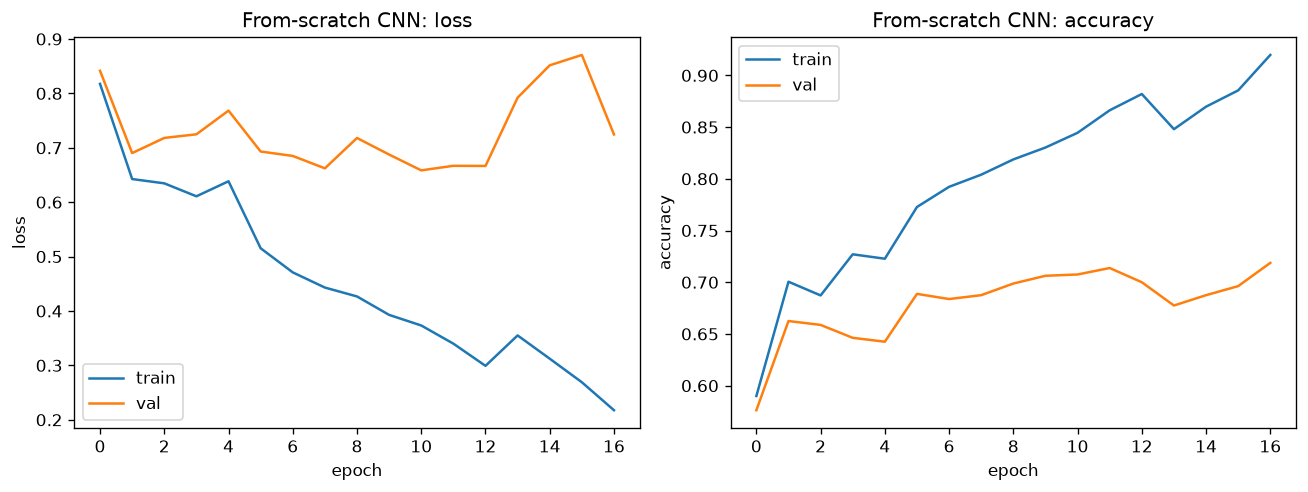

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(main_hist["train_losses"], label="train"); ax[0].plot(main_hist["val_losses"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("From-scratch CNN: loss"); ax[0].legend()
ax[1].plot(main_hist["train_accs"], label="train"); ax[1].plot(main_hist["val_accs"], label="val")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("From-scratch CNN: accuracy"); ax[1].legend()
fig.tight_layout(); plt.show()

### C5: evaluation -- accuracy/precision/recall/F1/confusion matrix

Accuracy 0.7275 | Precision 0.7237 | Recall 0.7275 | F1 0.7243


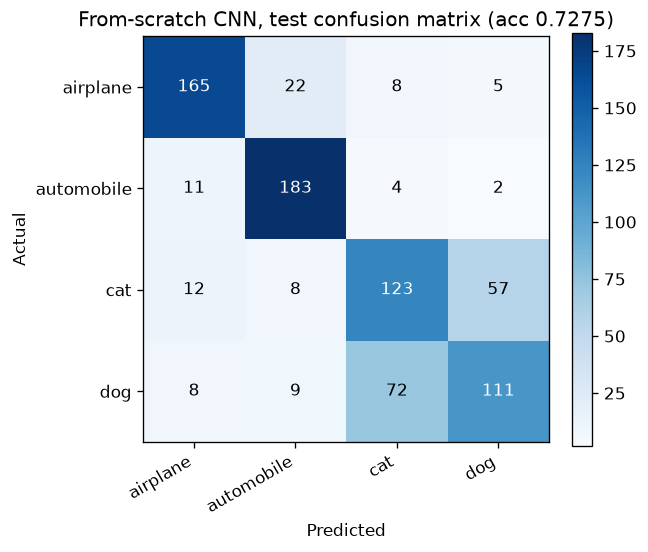

Most confused pair: true 'dog' -> predicted 'cat' (72 images)


In [14]:
def evaluate_numpy(net, X, y, name):
    preds = net.predict(X)
    return {"name": name, "accuracy": accuracy_score(y, preds),
            "precision": precision_score(y, preds, average="macro", zero_division=0),
            "recall": recall_score(y, preds, average="macro", zero_division=0),
            "f1": f1_score(y, preds, average="macro", zero_division=0), "cm": confusion_matrix(y, preds)}

numpy_test_result = evaluate_numpy(main_net, X_test, y_test, "NumPy CNN")
print(f"Accuracy {numpy_test_result['accuracy']:.4f} | Precision {numpy_test_result['precision']:.4f} | "
      f"Recall {numpy_test_result['recall']:.4f} | F1 {numpy_test_result['f1']:.4f}")

cm = numpy_test_result["cm"]
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"From-scratch CNN, test confusion matrix (acc {numpy_test_result['accuracy']:.4f})")
for r in range(4):
    for c in range(4):
        ax.text(c, r, str(cm[r,c]), ha="center", va="center", color="white" if cm[r,c]>cm.max()/2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046); fig.tight_layout(); plt.show()

cm_offdiag = cm.copy(); np.fill_diagonal(cm_offdiag, 0)
i, j = np.unravel_index(cm_offdiag.argmax(), cm_offdiag.shape)
print(f"Most confused pair: true '{CLASS_NAMES[i]}' -> predicted '{CLASS_NAMES[j]}' ({cm_offdiag[i,j]} images)")

### C6: PyTorch baseline, same architecture, trained on the same data

In [15]:
class TorchCNN(nn.Module):
    def __init__(self, c1=8, c2=16, k=3, num_classes=4, fc_hidden=64, dropout_p=0.3):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv2d(3, c1, k, padding=pad); self.bn1 = nn.BatchNorm2d(c1); self.pool1 = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(c1, c2, k, padding=pad); self.bn2 = nn.BatchNorm2d(c2); self.pool2 = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(c2*8*8, fc_hidden); self.dropout = nn.Dropout(dropout_p); self.fc2 = nn.Linear(fc_hidden, num_classes)
    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = x.flatten(1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

X_train_t = torch.tensor(X_train, dtype=torch.float32); y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32); y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32); y_test_t = torch.tensor(y_test, dtype=torch.long)

torch.manual_seed(RANDOM_STATE)
torch_net = TorchCNN()
optimizer = torch.optim.SGD(torch_net.parameters(), lr=LR, momentum=MOMENTUM)
criterion = nn.CrossEntropyLoss()
torch_hist = {"train_losses": [], "val_losses": [], "train_accs": [], "val_accs": []}
t0 = time.perf_counter()
for epoch in range(EPOCHS):
    torch_net.train()
    perm = torch.randperm(X_train_t.shape[0])
    for start in range(0, X_train_t.shape[0], BATCH_SIZE):
        idx = perm[start:start+BATCH_SIZE]
        optimizer.zero_grad()
        loss = criterion(torch_net(X_train_t[idx]), y_train_t[idx])
        loss.backward(); optimizer.step()
    torch_net.eval()
    with torch.no_grad():
        tr_logits, va_logits = torch_net(X_train_t), torch_net(X_val_t)
        tr_loss, va_loss = criterion(tr_logits, y_train_t).item(), criterion(va_logits, y_val_t).item()
        tr_acc = (tr_logits.argmax(1)==y_train_t).float().mean().item()
        va_acc = (va_logits.argmax(1)==y_val_t).float().mean().item()
    torch_hist["train_losses"].append(tr_loss); torch_hist["val_losses"].append(va_loss)
    torch_hist["train_accs"].append(tr_acc); torch_hist["val_accs"].append(va_acc)
    print(f"  [torch] epoch {epoch+1:2d}/{EPOCHS}  train loss {tr_loss:.4f}  val loss {va_loss:.4f}  train acc {tr_acc:.4f}  val acc {va_acc:.4f}")
torch_hist["train_time"] = time.perf_counter() - t0
print(f"PyTorch training time: {torch_hist['train_time']:.2f}s")

  [torch] epoch  1/25  train loss 0.7233  val loss 0.7699  train acc 0.6327  val acc 0.6175


  [torch] epoch  2/25  train loss 0.6441  val loss 0.7495  train acc 0.7225  val acc 0.6700


  [torch] epoch  3/25  train loss 0.5371  val loss 0.6638  train acc 0.7607  val acc 0.7113


  [torch] epoch  4/25  train loss 0.5035  val loss 0.6367  train acc 0.7857  val acc 0.7250


  [torch] epoch  5/25  train loss 0.5035  val loss 0.7163  train acc 0.7790  val acc 0.6837


...

  [torch] epoch 21/25  train loss 0.0750  val loss 1.1036  train acc 0.9755  val acc 0.7362


  [torch] epoch 22/25  train loss 0.0758  val loss 1.1421  train acc 0.9772  val acc 0.7038


  [torch] epoch 23/25  train loss 0.1011  val loss 1.0681  train acc 0.9647  val acc 0.7188


  [torch] epoch 24/25  train loss 0.0838  val loss 1.1671  train acc 0.9772  val acc 0.7075


  [torch] epoch 25/25  train loss 0.0610  val loss 1.1451  train acc 0.9825  val acc 0.7138
PyTorch training time: 65.20s


PyTorch TEST: Acc 0.7300 | F1 0.7306
NumPy   TEST: Acc 0.7275 | F1 0.7243
Accuracy gap: 0.0025


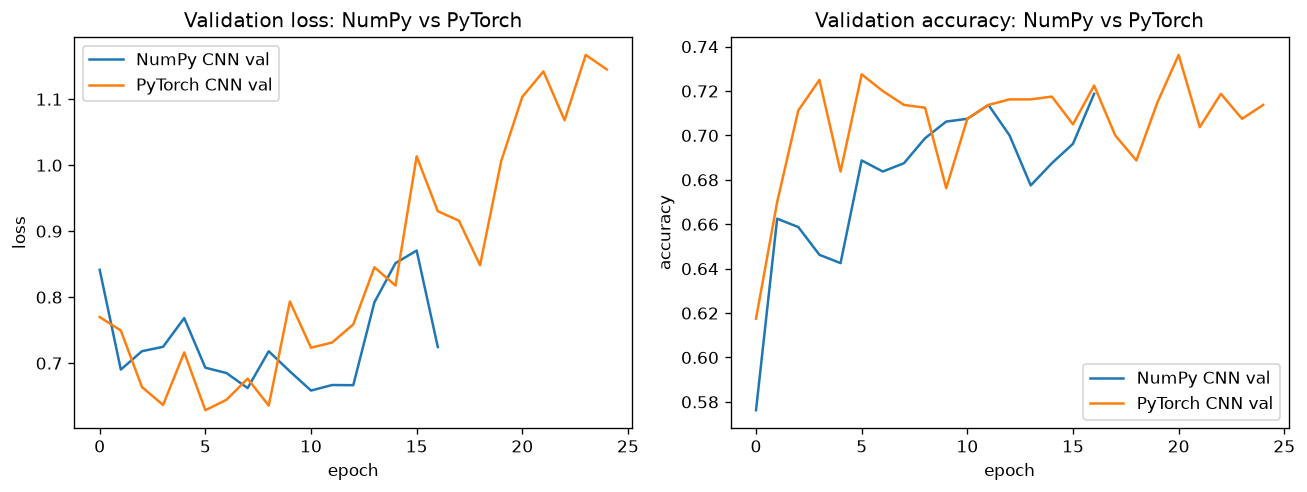

In [16]:
torch_net.eval()
with torch.no_grad():
    torch_test_preds = torch_net(X_test_t).argmax(1).numpy()
torch_test_acc = accuracy_score(y_test, torch_test_preds)
torch_test_f1 = f1_score(y_test, torch_test_preds, average="macro")
print(f"PyTorch TEST: Acc {torch_test_acc:.4f} | F1 {torch_test_f1:.4f}")
print(f"NumPy   TEST: Acc {numpy_test_result['accuracy']:.4f} | F1 {numpy_test_result['f1']:.4f}")
print(f"Accuracy gap: {abs(torch_test_acc - numpy_test_result['accuracy']):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(main_hist["val_losses"], label="NumPy CNN val"); ax[0].plot(torch_hist["val_losses"], label="PyTorch CNN val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Validation loss: NumPy vs PyTorch"); ax[0].legend()
ax[1].plot(main_hist["val_accs"], label="NumPy CNN val"); ax[1].plot(torch_hist["val_accs"], label="PyTorch CNN val")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("Validation accuracy: NumPy vs PyTorch"); ax[1].legend()
fig.tight_layout(); plt.show()

### C7: ablation study -- kernel size x downsampling mechanism

In [17]:
ablation_configs = {
    "Baseline (3x3, max pool)": dict(kernel_size=3, use_pooling=True),
    "Larger kernel (5x5, max pool)": dict(kernel_size=5, use_pooling=True),
    "No pooling (3x3, stride-2 conv)": dict(kernel_size=3, use_pooling=False),
}
ablation_results = {}
for name, cfg in ablation_configs.items():
    print(f"--- Training: {name} ---")
    net = SimpleCNN(input_shape=(3,32,32), num_classes=4, conv_channels=(8,16),
                     use_batchnorm=True, use_dropout=True, dropout_p=0.3, fc_hidden=64,
                     seed=RANDOM_STATE, **cfg)
    hist = train_numpy_cnn(net, epochs=20, verbose_name=name.split()[0].lower())
    test_res = evaluate_numpy(net, X_test, y_test, name)
    n_params = sum(p.size for p in [net.conv1.W, net.conv1.b, net.conv2.W, net.conv2.b,
                                     net.fc1.W, net.fc1.b, net.fc2.W, net.fc2.b])
    if not cfg["use_pooling"]:
        n_params += net.down1.W.size + net.down1.b.size + net.down2.W.size + net.down2.b.size
    ablation_results[name] = {"hist": hist, "test": test_res, "n_params": n_params, "net": net}
    print(f"{name}: TEST acc {test_res['accuracy']:.4f} | params {n_params:,} | time {hist['train_time']:.2f}s")

--- Training: Baseline (3x3, max pool) ---


  [baseline] epoch  1/20  train loss 0.8175  val loss 0.8415  train acc 0.5900  val acc 0.5763


  [baseline] epoch  2/20  train loss 0.6426  val loss 0.6903  train acc 0.7005  val acc 0.6625


  [baseline] epoch  3/20  train loss 0.6347  val loss 0.7181  train acc 0.6873  val acc 0.6587


  [baseline] epoch  4/20  train loss 0.6108  val loss 0.7248  train acc 0.7270  val acc 0.6462


...

  [no] epoch 17/20  train loss 0.0809  val loss 1.0813  train acc 0.9772  val acc 0.6900


  [no] epoch 18/20  train loss 0.0849  val loss 1.0117  train acc 0.9785  val acc 0.6687


  [no] epoch 19/20  train loss 0.0485  val loss 1.3625  train acc 0.9840  val acc 0.6800


  [no] epoch 20/20  train loss 0.0501  val loss 1.2336  train acc 0.9885  val acc 0.6825


No pooling (3x3, stride-2 conv): TEST acc 0.7087 | params 68,556 | time 307.61s


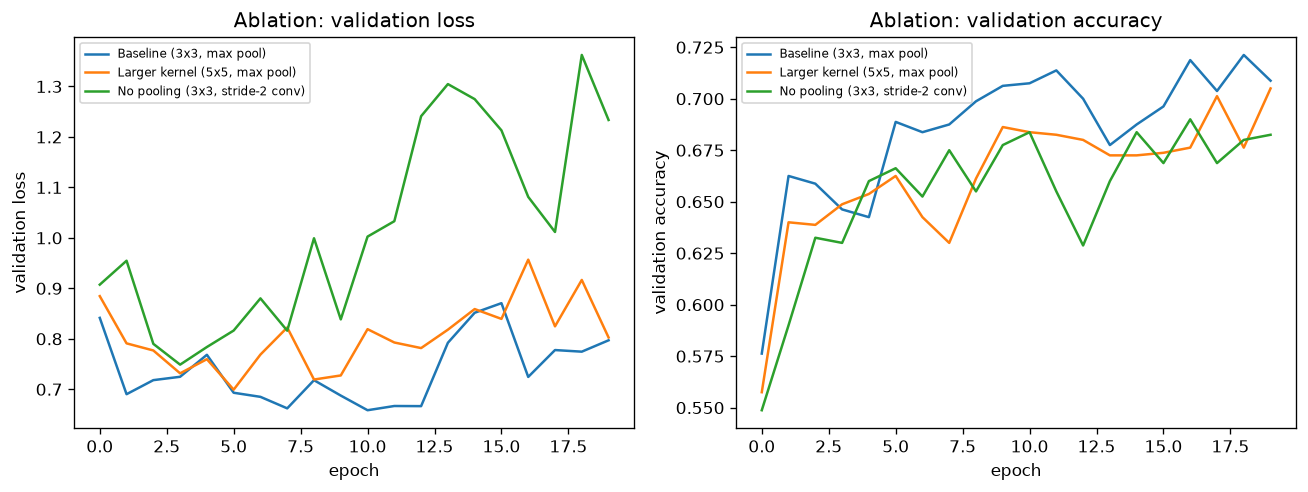

  Baseline (3x3, max pool)            TEST acc 0.7188 | params 67,252 | time 387.91s
  Larger kernel (5x5, max pool)       TEST acc 0.7175 | params 69,684 | time 571.89s
  No pooling (3x3, stride-2 conv)     TEST acc 0.7087 | params 68,556 | time 307.61s


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, r in ablation_results.items():
    ax[0].plot(r["hist"]["val_losses"], label=name)
    ax[1].plot(r["hist"]["val_accs"], label=name)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("validation loss"); ax[0].set_title("Ablation: validation loss"); ax[0].legend(fontsize=7)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation accuracy"); ax[1].set_title("Ablation: validation accuracy"); ax[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

for name, r in ablation_results.items():
    print(f"  {name:35s} TEST acc {r['test']['accuracy']:.4f} | params {r['n_params']:6,} | time {r['hist']['train_time']:6.2f}s")

### C8: visualize learned first-layer filters and feature maps

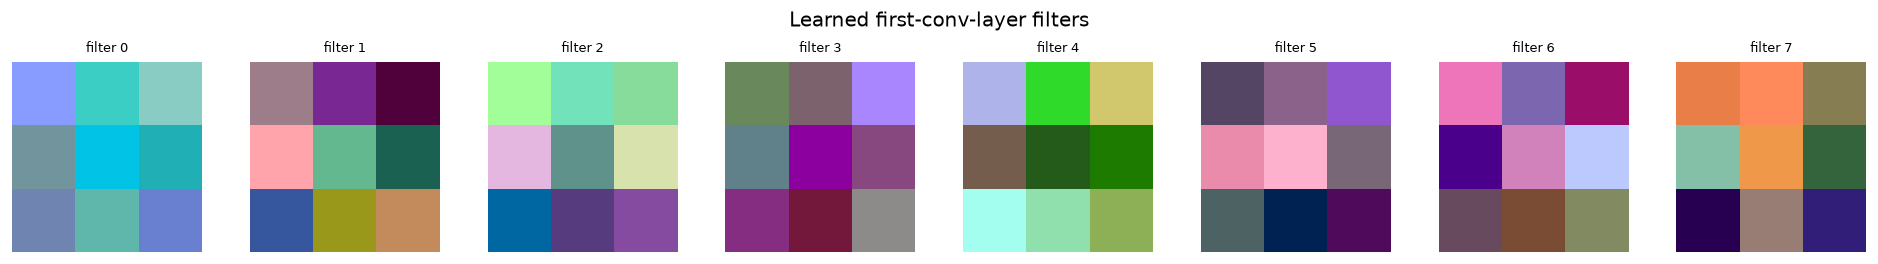

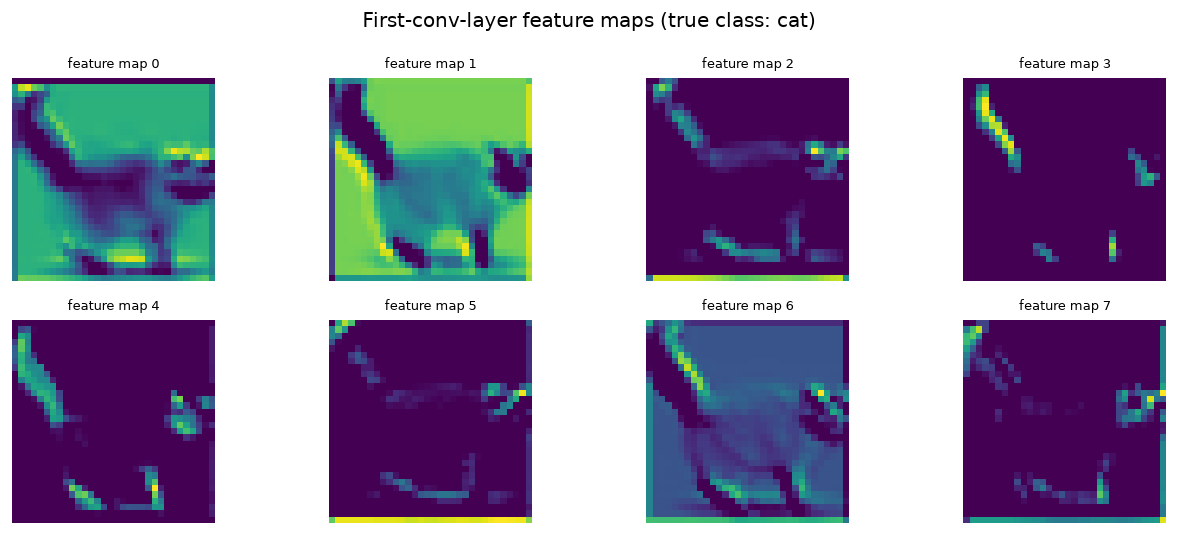

In [19]:
W1 = main_net.conv1.W
n_filters = W1.shape[0]
fig, axes = plt.subplots(1, n_filters, figsize=(2*n_filters, 2.2))
for i in range(n_filters):
    kernel = W1[i].transpose(1,2,0)
    kernel_norm = (kernel - kernel.min()) / (kernel.max() - kernel.min() + 1e-8)
    axes[i].imshow(kernel_norm); axes[i].set_title(f"filter {i}", fontsize=8); axes[i].axis("off")
fig.suptitle("Learned first-conv-layer filters"); fig.tight_layout(); plt.show()

sample_idx = 0
sample_img = X_test[sample_idx:sample_idx+1]
z1 = main_net.conv1.forward(sample_img, training=False)
a1 = np.maximum(0, main_net.bn1.forward(z1, training=False) if main_net.use_batchnorm else z1)
fig, axes = plt.subplots(2, n_filters//2 + n_filters%2, figsize=(2.2*(n_filters//2+1), 4.5))
axes = axes.ravel()
for i in range(n_filters):
    axes[i].imshow(a1[0,i], cmap="viridis"); axes[i].set_title(f"feature map {i}", fontsize=8); axes[i].axis("off")
for i in range(n_filters, len(axes)):
    axes[i].axis("off")
fig.suptitle(f"First-conv-layer feature maps (true class: {CLASS_NAMES[y_test[sample_idx]]})")
fig.tight_layout(); plt.show()

In [20]:
model_data = {
    "params": main_net.get_params(),
    "architecture": dict(input_shape=(3,32,32), num_classes=4, conv_channels=(8,16),
                          kernel_size=3, use_pooling=True, use_batchnorm=True,
                          use_dropout=True, dropout_p=0.3, fc_hidden=64),
    "class_names": CLASS_NAMES, "normalization": {"mean": mean, "std": std},
    "test_accuracy": float(numpy_test_result["accuracy"]), "test_f1": float(numpy_test_result["f1"]),
}
with open("numpy_cnn_final_model.pkl", "wb") as f:
    pickle.dump(model_data, f)
print("Saved numpy_cnn_final_model.pkl")

Saved numpy_cnn_final_model.pkl


## Part D: Analysis & Documentation

### D3: effective receptive field, computed

In [21]:
def effective_receptive_field(layers, verbose_name=""):
    r, jump = 1, 1
    trace = [(r, jump)]
    for k, s in layers:
        r = r + (k-1)*jump; jump = jump*s
        trace.append((r, jump))
    print(f"{verbose_name}: final RF = {r}x{r}")
    return r

baseline_layers = [(3,1),(2,2),(3,1),(2,2)]
larger_kernel_layers = [(5,1),(2,2),(5,1),(2,2)]
no_pooling_layers = [(3,1),(2,2),(3,1),(2,2)]

rf_baseline = effective_receptive_field(baseline_layers, "Baseline (3x3, max pool)")
rf_larger = effective_receptive_field(larger_kernel_layers, "Larger kernel (5x5, max pool)")
rf_nopool = effective_receptive_field(no_pooling_layers, "No pooling (3x3, stride-2 conv)")
print(f"\nBaseline RF={rf_baseline}x{rf_baseline}, larger-kernel RF={rf_larger}x{rf_larger}, "
      f"no-pooling RF={rf_nopool}x{rf_nopool} (identical to baseline -- stride-2 conv has the same "
      f"(kernel,stride) footprint as 2x2 max pool)")

Baseline (3x3, max pool): final RF = 10x10
Larger kernel (5x5, max pool): final RF = 16x16
No pooling (3x3, stride-2 conv): final RF = 10x10

Baseline RF=10x10, larger-kernel RF=16x16, no-pooling RF=10x10 (identical to baseline -- stride-2 conv has the same (kernel,stride) footprint as 2x2 max pool)


### D4: ablation findings, D5: NumPy vs PyTorch, D6: challenges, D7: framework limitations

Full discussion in `Report.pdf` Part D and `part_d_analysis.py` -- summary:

- **Larger kernel (5x5) did not help** despite 60% bigger receptive field and more
  parameters (0.7175 vs 0.7188 baseline) -- on this small, low-resolution dataset, extra
  capacity bought overfitting, not signal.
- **Removing pooling measurably hurt generalization** (0.7087) despite an IDENTICAL
  receptive field to the baseline -- confirms the effect is pooling's translation-invariance
  regularization, not receptive field size; the no-pooling variant's validation loss
  visibly diverges upward while train accuracy reaches 98.9%.
- **NumPy vs PyTorch**: 0.7275 vs 0.7300 test accuracy (0.25 point gap) with identical
  architecture/optimizer/data -- strong evidence the from-scratch backward-pass math is
  correct, not just gradient-check-correct in isolation. PyTorch trained ~5.2x faster
  (cuDNN-level kernel fusion/algorithm selection this implementation doesn't have).
- **Two real challenges**: (1) max-pool gradient checks showing expected argmax-tie
  outliers, resolved by substituting AvgPool2D to isolate and confirm correct backward
  wiring; (2) an apparently-hung 20-minute training run that was actually healthy --
  concurrent benchmarking commands were starving it of CPU, resolved by isolating the run
  and using unbuffered output for visibility.